# Setup VM

## Using Existing Instance

### Choose Site and Project 

In [31]:
from chi import context

context.version = "1.0"

context.use_site("CHI@UC") #change to your site 
context.use_project("CHI-251412") # change to your porject

Now using CHI@UC:
URL: https://chi.uc.chameleoncloud.org
Location: Argonne National Laboratory, Lemont, Illinois, USA
Support contact: help@chameleoncloud.org
Now using project: CHI-251412


### Connect to Server

In [4]:
from chi import server

my_server = server.get_server("maicbf-instance") #change to your instance name
print("Server Status : ", my_server.status)
my_server.check_connectivity()

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Server Status :  ACTIVE
Checking connectivity to 192.5.87.209 port 22.


Connection successful


In [5]:
my_server.execute("python3 --version")

/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 192.5.87.209: b'7b3ce5721f13617b9559f4ce27a650c1'
  warnings.warn(


Python 3.10.12


<Result cmd='python3 --version' exited=0>

## Using New Instance

In [2]:
from chi import context

context.version = "1.0"
context.choose_site(default="CHI@TACC")
context.choose_project()

TypeError: choose_project() takes 0 positional arguments but 1 was given

In [ ]:
from chi import hardware

node_type = "compute_cascadelake_r"
available_nodes = hardware.get_nodes(node_type=node_type, filter_reserved=True)
if available_nodes:
    print(f"There currently are {len(available_nodes)} {node_type} nodes ready to use")
    hardware.show_nodes(available_nodes)
else:
    print(f"All {node_type} nodes are in use! You could use next_free_timeslot to see how long you need to wait, or use the calendar.")

In [ ]:
from chi import lease
from datetime import timedelta
import os

my_lease = lease.Lease(f"{os.getenv('USER')}-maicbf", duration=timedelta(hours=3))
my_lease.add_node_reservation(nodes=[available_nodes[0]])
my_lease.add_fip_reservation(1)
my_lease.submit(idempotent=True)

In [ ]:
from chi import server

my_server = server.Server(
    f"{os.getenv('USER')}-maicbf",
    reservation_id=my_lease.node_reservations[0]["id"],
    image_name="CC-Ubuntu22.04", # or use image_name
)
my_server.submit(idempotent=True)

In [ ]:
fip = my_lease.get_reserved_floating_ips()[0]
my_server.associate_floating_ip(fip)
my_server.check_connectivity(host=fip)

# Setup Environment

Create a Conda virtual environment to run this. Make sure Conda (or Miniconda) was installed beforehand. This is required to make sure the code can run smoothly using python 3.6

In [6]:
#check if conda was installed
my_server.execute("ls /opt/conda/bin/conda || ls ~/miniconda3/bin/conda")

ls: cannot access '/opt/conda/bin/conda': No such file or directory


/home/cc/miniconda3/bin/conda


<Result cmd='ls /opt/conda/bin/conda || ls ~/miniconda3/bin/conda' exited=0>

In [100]:
#create virtual env
conda = "~/miniconda3/bin/conda"
my_server.execute(f"{conda} create -n maicbf python=3.6 -y") 
my_server.execute("ls ~/miniconda3/envs")

/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 192.5.87.209: b'7b3ce5721f13617b9559f4ce27a650c1'
  warnings.warn(


2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/cc/miniconda3/envs/maicbf

  added / updated specs:
    - python=3.6


The following NEW packages will be INSTALLED:

  _libgcc_mutex      pkgs/main/linux-64::_libgcc_mutex-0.1-main 
  _openmp_mutex      pkgs/main/linux-64::_openmp_mutex-5.1-1_gnu 
  ca-certificates    pkgs/main/linux-64::ca-certificates-2025.12.2-h06a4308_0 
  certifi            pkgs/main/linux-64::certifi-2021.5.30-py36h06a4308_0 
  ld_impl_linux-64   pkgs/main/linux-64::ld_impl_linux-64-2.44-h153f514_2 
  libffi             pkgs/main/linux-64::libffi-3.3-he6710b0_2 
  libgcc             pkgs/main/linux-64::libgcc-15.2.0-h69a1729_7 
  libgcc-ng          pkgs/main/linux-64::libgcc-ng-15.2.0-h166f726_7 
  libgomp            pkgs/main/linux-64::libgomp-15.2.0-h4751f2c_7 
  libstdcxx          pkgs/main/linux-64::libstdcxx-15.2.0-h39759b7_7 
  libstdcxx-ng       pkgs/mai

<Result cmd='ls ~/miniconda3/envs' exited=0>

In [7]:
#check if maicbf env ready to use
#to use the specific environment through this notebook, the path is required
cenv = "~/miniconda3/envs/maicbf/bin/"
my_server.execute(f"{cenv}python --version")

Python 3.6.13 :: Anaconda, Inc.


<Result cmd='~/miniconda3/envs/maicbf/bin/python --version' exited=0>

In [30]:
#clone project repo
my_server.execute("cd Documents && git clone https://github.com/anisamsrh/MA-ICBF_Reproduction_Artifacts")

Cloning into 'maicbf'...
Updating files: 100% (571/571), done.


<Result cmd='git clone https://github.com/abj247/maicbf.git' exited=0>

In [33]:
#install project's required libraries
my_server.execute(f"{cenv}pip install -r requirements.txt")

<Result cmd='cd maicbf && ~/miniconda3/envs/maicbf/bin/pip install -r requirements.txt' exited=0>

In [211]:
#install another required libraries that are not listed in requirements.txt
my_server.execute(f"{cenv}pip install pandas cvxpy matplotlib")

  Using cached pandas-1.1.5-cp36-cp36m-manylinux1_x86_64.whl (9.5 MB)
  Using cached cvxpy-1.1.24-cp36-cp36m-manylinux_2_24_x86_64.whl (2.7 MB)
  Using cached matplotlib-3.3.4-cp36-cp36m-manylinux1_x86_64.whl (11.5 MB)
  Using cached numpy-1.19.5-cp36-cp36m-manylinux2010_x86_64.whl (14.8 MB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached osqp-0.6.7.post3-cp36-cp36m-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (233 kB)
  Using cached scs-3.2.3-cp36-cp36m-linux_x86_64.whl
  Using cached scipy-1.5.4-cp36-cp36m-manylinux1_x86_64.whl (25.9 MB)
  Using cached ecos-2.0.14-cp36-cp36m-linux_x86_64.whl
  Using cached kiwisolver-1.3.1-cp36-cp36m-manylinux1_x86_64.whl (1.1 MB)
  Using cached Pillow-8.4.0-cp36-cp36m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.1 MB)
  Using cached cycler-0.11.0-py3-none-any.whl (6.4 kB)
  Using cached qdldl-0.1.7.post5-cp36-cp36m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.

<Result cmd='~/miniconda3/envs/maicbf/bin/pip install pandas cvxpy matplotlib' exited=0>

In [8]:
#install library to store csv file in ObjectStorage ChameleonCloud
bucket_name = "maicbf"
my_server.execute(f"{cenv}pip install python-swiftclient python-keystoneclient")
my_server.execute(f"source ~/openrc.sh && {cenv}swift post {bucket_name}")

<Result cmd='source ~/openrc.sh && ~/miniconda3/envs/maicbf/bin/swift post maicbf' exited=0>

# Reproduction

## Training

In [ ]:
#create directory for logging
my_server.execute("cd Documents/maicbf && mkdir -p train_logs && mkdir -p csv_data/losses && mkdir -p csv_data/trajectory")
#start tmux session
my_server.execute("tmux new -d -s train_batch")

In [ ]:
my_server.execute(f"tmux send-key -t train_batch 'conda activate maicbf && cd ~/Documents/maicbf' C-m")

In [ ]:
num_agents = 4
my_server.execute(f"tmux send-key -t train_batch 'python train.py --num_agents {num_agents}' C-m")

In [ ]:
#kill session when done
my_server.execute("tmux kill-session -t train_batch")

## Evaluation

In [36]:
# create directory for evaluation data and clean old saved data
my_server.execute("cd Documents/maicbf && if [ ! -d "csv_data" ]; then mkdir csv_data; else rm -rf csv_data/metrics_summary/*; fi")

<Result cmd='cd maicbf && mkdir csv_data' exited=0>

In [135]:
my_server.upload("./ma-icbf/run_all.sh", "/home/cc/Documents/maicbf/run_all.sh")
print("File uploaded!")

In [193]:
my_server.execute(f"tmux new -d -s batch")

<Result cmd='tmux new -d -s batch4' exited=0>

In [209]:
my_server.execute(f"tmux send-key -t batch 'conda activate maicbf && cd ~/Documents/maicbf' C-m")

<Result cmd="tmux send-key -t batch4 'conda activate maicbf && cd ~/Documents/maicbf' C-m" exited=0>

In [213]:
my_server.execute(f"tmux send-key -t batch 'bash ~/Documents/maicbf/run_all.sh' C-m")

<Result cmd="tmux send-key -t batch4 'bash ~/Documents/maicbf/run_all.sh' C-m" exited=0>

In [225]:
#this command is to watch current run_all.sh progress
result = my_server.execute("tmux capture-pane -pt batch")
print(result)

/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 192.5.87.209: b'7b3ce5721f13617b9559f4ce27a650c1'
  warnings.warn(



Number of objective function evaluations             = 0
Number of objective gradient evaluations             = 0
Number of equality constraint evaluations            = 0
Number of inequality constraint evaluations          = 1
Number of equality constraint Jacobian evaluations   = 0
Number of inequality constraint Jacobian evaluations = 0
Number of Lagrangian Hessian evaluations             = 0
Total CPU secs in IPOPT (w/o function evaluations)   =      0.001
Total CPU secs in NLP function evaluations           =      0.000

EXIT: Invalid number in NLP function or derivative detected.
           S  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_g  |  45.00us ( 45.00us)  46.21us ( 46.21us)         1
    nlp_grad  |  39.00us ( 39.00us)  38.44us ( 38.44us)         1
  nlp_grad_f  |  16.00us ( 16.00us)  15.74us ( 15.74us)         1
   nlp_jac_g  | 201.00us (100.50us) 200.72us (100.36us)         2
       total  |   1.19ms (  1.19ms)   1.17ms (  1.17ms)         1
u_opt [[0.

In [ ]:
#kill session when done
my_server.execute("tmux kill-session -t eval_batch")

## Results

In [29]:
#download files
from chi import storage
b = storage.ObjectBucket(f"{bucket_name}")
for obj in b.list_objects():
    print(f"Downloading {obj.name}")
    obj.download(f"./csv_data/{obj.name}")

In [15]:
!pip install seaborn

Saved: plot_collision_avoidance.png
Saved: plot_deadlocks.png
Saved: plot_ic_satisfaction.png
Saved: plot_computational_time.png


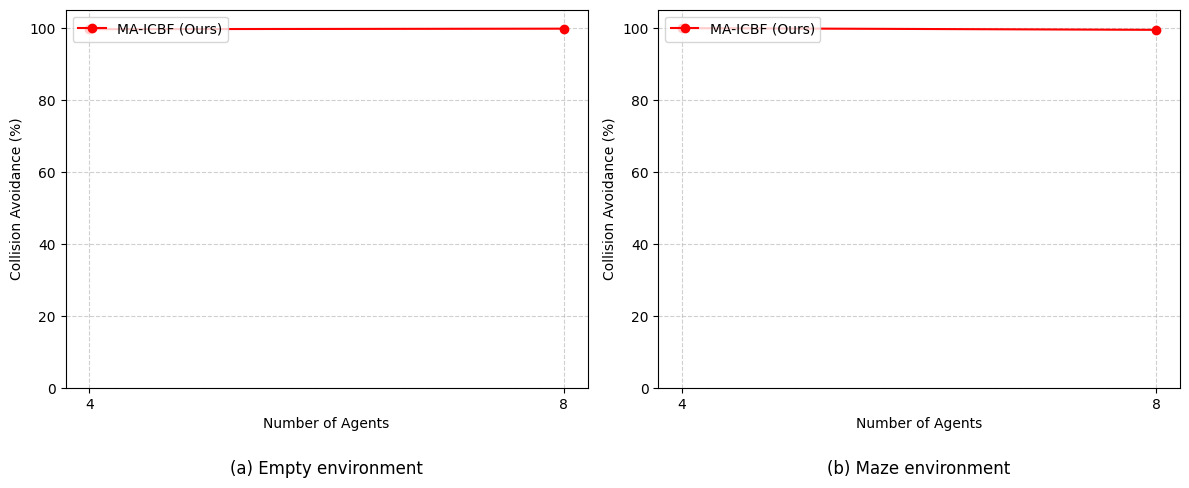

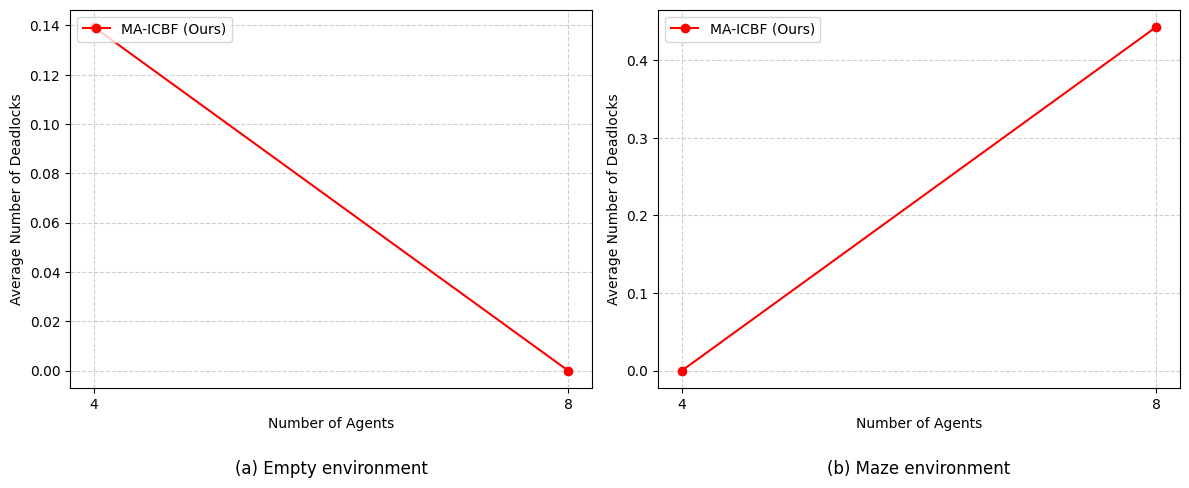

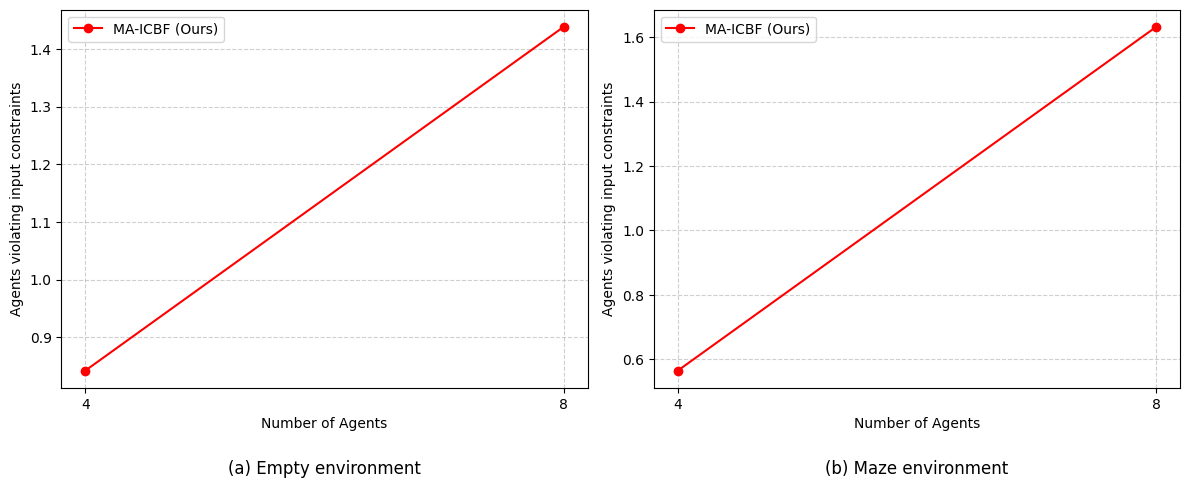

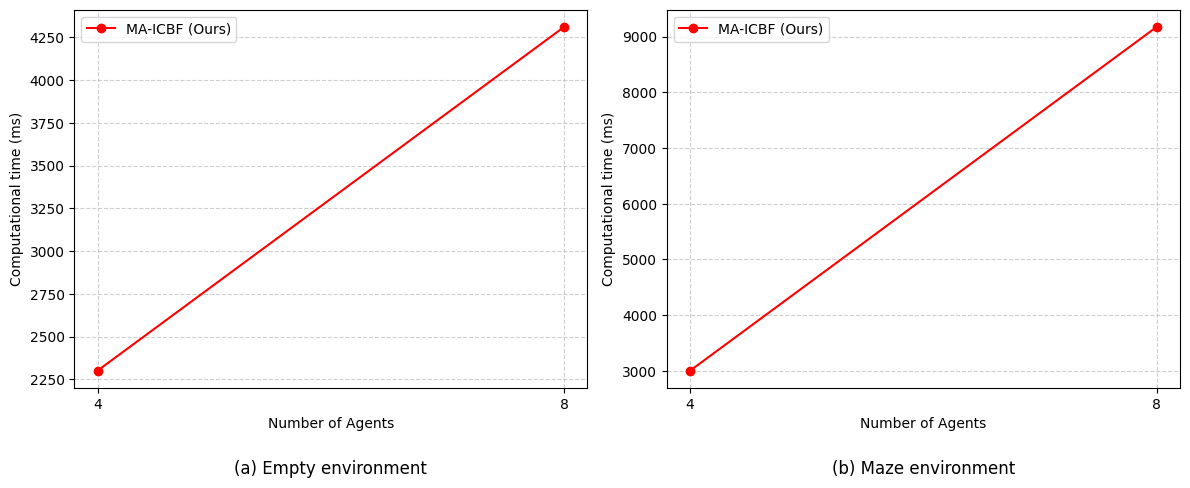

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def create_benchmark_plot(df, metric_column, y_label, title_suffix, save_name, y_limit=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    envs = [('Empty', ax1, '(a) Empty environment'), ('Maze', ax2, '(b) Maze environment')]
    
    # Konfigurasi style agar mirip gambar referensi
    style = {'marker': 'o', 'color': 'red', 'label': 'MA-ICBF (Ours)', 'linewidth': 1.5}

    for env_name, ax, sub_title in envs:
        data = df[df['env'] == env_name].sort_values('num_agents')
        if not data.empty:
            # Menggunakan log scale untuk X axis jika jumlah agent beragam (4, 8, 16... 1024)
            ax.plot(data['num_agents'].astype(str), data[metric_column], **style)
        
        ax.set_title(sub_title, y=-0.25)
        ax.set_ylabel(y_label)
        ax.set_xlabel('Number of Agents')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper left')
        if y_limit: ax.set_ylim(y_limit)

    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name}")

def main():
    results_dir = 'csv_data'
    all_files = glob.glob(os.path.join(results_dir, "summary_*.csv"))
    
    if not all_files:
        print("Data tidak ditemukan.")
        return

    # Gabungkan dan rata-ratakan data
    full_df = pd.concat([pd.read_csv(f) for f in all_files])
    summary = full_df.groupby(['env', 'num_agents']).mean().reset_index()

    # 1. Collision Avoidance Plot
    create_benchmark_plot(summary, 'collision_avoidance_rate', 
                         'Collision Avoidance (%)', 'Safety', 
                         'plot_collision_avoidance.png', y_limit=(0, 105))

    # 2. Deadlocks Plot
    create_benchmark_plot(summary, 'num_deadlocks', 
                         'Average Number of Deadlocks', 'Deadlocks', 
                         'plot_deadlocks.png')

    # 3. Input Constraint Satisfaction Plot
    create_benchmark_plot(summary, 'num_violating_ic', 
                         'Agents violating input constraints', 'IC Violations', 
                         'plot_ic_satisfaction.png')

    # 4. Computational Time Plot
    create_benchmark_plot(summary, 'comp_time_ms', 
                         'Computational time (ms)', 'Time', 
                         'plot_computational_time.png')

if __name__ == "__main__":
    main()